In [1]:
!pip install mysql-connector-python


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

## import and print Sql connector

In [3]:
import mysql.connector
print("Mysql Connector imported successfully!")

Mysql Connector imported successfully!


## connecting to sql database

In [4]:
conn=mysql.connector.connect(
    host="localhost",
    user="root",
    password="9345788114",
    database="Retail_Sales_analysis"
)
print("Connected successfully")

Connected successfully


## fetching All tables

In [5]:
cursor = conn.cursor()
cursor.execute("SHOW TABLES")
print(cursor.fetchall())

[('brands',), ('categories',), ('customer_segments',), ('customers',), ('order_items',), ('orders',), ('products',), ('staffs',), ('stocks',), ('stores',)]


## Load datasets from SQL
## Customers Datasets

In [6]:
import pandas as pdps

In [7]:
customers = pd.read_sql("SELECT * FROM customers", conn)
print("Loaded successfully")

Loaded successfully


C:\Users\A D M I N\AppData\Local\Temp\ipykernel_1292\1018479818.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)


In [8]:
print(customers)

      customer_id  first_name last_name           phone  \
0               1       Debra     Burks               0   
1               2       Kasha      Todd               0   
2               3      Tameka    Fisher               0   
3               4       Daryl    Spence               0   
4               5  Charolette      Rice  (916) 381-6003   
...           ...         ...       ...             ...   
1440         1441      Jamaal  Morrison               0   
1441         1442      Cassie     Cline               0   
1442         1443      Lezlie      Lamb               0   
1443         1444      Ivette     Estes               0   
1444         1445       Ester   Acevedo               0   

                        email                  street           city state  \
0       debra.burks@yahoo.com       9273 Thorne Ave.    Orchard Park    NY   
1        kasha.todd@yahoo.com        910 Vine Street        Campbell    CA   
2       tameka.fisher@aol.com   769C Honey Creek St.   Re

## fetching Orders Details

In [9]:
orders = pd.read_sql("SELECT * FROM orders", conn)
orders.head()

C:\Users\A D M I N\AppData\Local\Temp\ipykernel_1292\4152989156.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)


,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,shipping_status
0,1,259,4,01-01-2016,03-01-2016,03-01-2016,1,2,Delivered
1,2,1212,4,01-01-2016,04-01-2016,03-01-2016,2,6,Delivered
2,3,523,4,01-02-2016,05-01-2016,03-01-2016,2,7,Delivered
3,4,175,4,01-03-2016,04-01-2016,05-01-2016,1,3,Delivered
4,5,1324,4,01-03-2016,06-01-2016,06-01-2016,2,6,Delivered


## fetching Order items

In [10]:
order_items = pd.read_sql("SELECT * FROM order_items", conn)
order_items.head()

C:\Users\A D M I N\AppData\Local\Temp\ipykernel_1292\3042837174.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", conn)


,order_id,item_id,product_id,quantity,list_price,discount,Total price,Product_Name,Category Name
0,1,1,20,1,599.99,0.2,599.79,Electra Townie Original 7D EQ - Women's - 2016,Cruisers Bicycles
1,1,2,8,2,1799.99,0.1,3599.91,Trek Remedy 29 Carbon Frameset - 2016,Cruisers Bicycles
2,1,3,10,2,1549.00,0.1,3097.95,Surly Straggler - 2016,Cruisers Bicycles
3,1,4,16,2,599.99,0.1,1199.93,Electra Townie Original 7D EQ - 2016,Cruisers Bicycles
4,1,5,4,1,2899.99,0.2,2899.79,Trek Fuel EX 8 29 - 2016,Cruisers Bicycles


## Basic EDA (Exploratory Data Analysis) 

## fetching Customers info and describe

In [11]:
customers.info()
customers.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  1445 non-null   int64
 1   first_name   1445 non-null   str  
 2   last_name    1445 non-null   str  
 3   phone        1445 non-null   str  
 4   email        1445 non-null   str  
 5   street       1445 non-null   str  
 6   city         1445 non-null   str  
 7   state        1445 non-null   str  
 8   zip_code     1445 non-null   int64
dtypes: int64(2), str(7)
memory usage: 101.7 KB


,customer_id,zip_code
count,1445.000000,1445.000000
mean,723.000000,34200.015225
std,417.279882,34733.933551
min,1.000000,10002.000000
25%,362.000000,11419.000000
50%,723.000000,11967.000000
75%,1084.000000,76110.000000
max,1445.000000,95993.000000


## fetching orders info and describe

In [12]:
orders.info()
orders.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   order_id         1615 non-null   int64
 1   customer_id      1615 non-null   int64
 2   order_status     1615 non-null   int64
 3   order_date       1615 non-null   str  
 4   required_date    1615 non-null   str  
 5   shipped_date     1615 non-null   str  
 6   store_id         1615 non-null   int64
 7   staff_id         1615 non-null   int64
 8   shipping_status  1615 non-null   str  
dtypes: int64(5), str(4)
memory usage: 113.7 KB


,order_id,customer_id,order_status,store_id,staff_id
count,1615.000000,1615.000000,1615.000000,1615.000000,1615.000000
mean,808.000000,654.171517,3.778947,1.892260,5.855108
std,466.354658,443.229967,0.693430,0.558395,1.913899
min,1.000000,1.000000,1.000000,1.000000,2.000000
25%,404.500000,237.000000,4.000000,2.000000,6.000000
50%,808.000000,638.000000,4.000000,2.000000,6.000000
75%,1211.500000,1041.500000,4.000000,2.000000,7.000000
max,1615.000000,1445.000000,4.000000,3.000000,9.000000


## fetching  orderitems info and describe

In [13]:
order_items.info()
order_items.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       4722 non-null   int64  
 1   item_id        4722 non-null   int64  
 2   product_id     4722 non-null   int64  
 3   quantity       4722 non-null   int64  
 4   list_price     4722 non-null   float64
 5   discount       4722 non-null   float64
 6   Total price    4722 non-null   float64
 7   Product_Name   4722 non-null   str    
 8   Category Name  4722 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 332.1 KB


,order_id,item_id,product_id,quantity,list_price,discount,Total price
count,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000
mean,821.265354,2.262601,59.366158,1.498941,1212.707872,0.125476,1816.707181
std,465.152168,1.199129,67.312708,0.500052,1352.798257,0.043578,2228.162327
min,1.000000,1.000000,2.000000,1.000000,89.990000,0.100000,89.790000
25%,423.250000,1.000000,14.000000,1.000000,429.000000,0.100000,539.780000
50%,828.500000,2.000000,28.000000,1.000000,599.990000,0.100000,939.910000
75%,1226.000000,3.000000,84.000000,2.000000,1549.000000,0.200000,1999.910000
max,1615.000000,5.000000,315.000000,2.000000,11999.990000,0.200000,23999.880000


## df.info()

In [14]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  1445 non-null   int64
 1   first_name   1445 non-null   str  
 2   last_name    1445 non-null   str  
 3   phone        1445 non-null   str  
 4   email        1445 non-null   str  
 5   street       1445 non-null   str  
 6   city         1445 non-null   str  
 7   state        1445 non-null   str  
 8   zip_code     1445 non-null   int64
dtypes: int64(2), str(7)
memory usage: 101.7 KB


In [15]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   order_id         1615 non-null   int64
 1   customer_id      1615 non-null   int64
 2   order_status     1615 non-null   int64
 3   order_date       1615 non-null   str  
 4   required_date    1615 non-null   str  
 5   shipped_date     1615 non-null   str  
 6   store_id         1615 non-null   int64
 7   staff_id         1615 non-null   int64
 8   shipping_status  1615 non-null   str  
dtypes: int64(5), str(4)
memory usage: 113.7 KB


In [16]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       4722 non-null   int64  
 1   item_id        4722 non-null   int64  
 2   product_id     4722 non-null   int64  
 3   quantity       4722 non-null   int64  
 4   list_price     4722 non-null   float64
 5   discount       4722 non-null   float64
 6   Total price    4722 non-null   float64
 7   Product_Name   4722 non-null   str    
 8   Category Name  4722 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 332.1 KB


## df.describe()

In [17]:
customers.describe(include='all')

,customer_id,first_name,last_name,phone,email,street,city,state,zip_code
count,1445.000000,1445,1445,1445,1445,1445,1445,1445,1445.000000
unique,NaN,1265,753,179,1445,1445,195,3,NaN
top,NaN,Genoveva,Larson,0,debra.burks@yahoo.com,9273 Thorne Ave.,Mount Vernon,NY,NaN
freq,NaN,3,7,1267,1,1,20,1019,NaN
mean,723.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34200.015225
std,417.279882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34733.933551
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10002.000000
25%,362.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11419.000000
50%,723.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11967.000000
75%,1084.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76110.000000


In [18]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,shipping_status
count,1615.000000,1615.000000,1615.000000,1615,1615,1615,1615.000000,1615.000000,1615
unique,NaN,NaN,NaN,725,734,676,NaN,NaN,4
top,NaN,NaN,NaN,04-12-2018,12-04-2018,02-04-2018,NaN,NaN,Delivered
freq,NaN,NaN,NaN,9,9,140,NaN,NaN,1445
mean,808.000000,654.171517,3.778947,NaN,NaN,NaN,1.892260,5.855108,NaN
std,466.354658,443.229967,0.693430,NaN,NaN,NaN,0.558395,1.913899,NaN
min,1.000000,1.000000,1.000000,NaN,NaN,NaN,1.000000,2.000000,NaN
25%,404.500000,237.000000,4.000000,NaN,NaN,NaN,2.000000,6.000000,NaN
50%,808.000000,638.000000,4.000000,NaN,NaN,NaN,2.000000,6.000000,NaN
75%,1211.500000,1041.500000,4.000000,NaN,NaN,NaN,2.000000,7.000000,NaN


In [19]:
order_items.describe(include='all')

,order_id,item_id,product_id,quantity,list_price,discount,Total price,Product_Name,Category Name
count,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722,4722
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278,8
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electra Townie Original 21D - 2016,
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193,3107
mean,821.265354,2.262601,59.366158,1.498941,1212.707872,0.125476,1816.707181,NaN,NaN
std,465.152168,1.199129,67.312708,0.500052,1352.798257,0.043578,2228.162327,NaN,NaN
min,1.000000,1.000000,2.000000,1.000000,89.990000,0.100000,89.790000,NaN,NaN
25%,423.250000,1.000000,14.000000,1.000000,429.000000,0.100000,539.780000,NaN,NaN
50%,828.500000,2.000000,28.000000,1.000000,599.990000,0.100000,939.910000,NaN,NaN
75%,1226.000000,3.000000,84.000000,2.000000,1549.000000,0.200000,1999.910000,NaN,NaN


## isnull value

In [20]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
phone          0
email          0
street         0
city           0
state          0
zip_code       0
dtype: int64

In [21]:
orders.isnull().sum()

order_id           0
customer_id        0
order_status       0
order_date         0
required_date      0
shipped_date       0
store_id           0
staff_id           0
shipping_status    0
dtype: int64

In [22]:
order_items.isnull().sum()

order_id         0
item_id          0
product_id       0
quantity         0
list_price       0
discount         0
Total price      0
Product_Name     0
Category Name    0
dtype: int64

In [23]:
orders= orders.fillna(0)

In [24]:
orders.tail(10)

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,shipping_status
1605,1606,119,3,07-10-2018,10-07-2018,02-04-2018,3,8,Shipped
1606,1607,33,3,07-11-2018,11-07-2018,02-04-2018,1,2,Shipped
1607,1608,53,3,07-12-2018,12-07-2018,02-04-2018,1,2,Shipped
1608,1609,10,3,08-23-18,23-08-2018,02-04-2018,2,7,Shipped
1609,1610,15,3,08-25-18,25-08-2018,02-04-2018,2,7,Shipped
1610,1611,6,3,09-06-2018,06-09-2018,02-04-2018,2,7,Shipped
1611,1612,3,3,10-21-18,21-10-2018,02-04-2018,1,3,Shipped
1612,1613,1,3,11-18-18,18-11-2018,02-04-2018,2,6,Shipped
1613,1614,135,3,11-28-18,28-11-2018,02-04-2018,3,8,Shipped
1614,1615,136,3,12-28-18,28-12-2018,02-04-2018,3,8,Shipped


## duplicate values

In [25]:
customers.duplicated().sum()

np.int64(0)

In [26]:
orders.duplicated().sum()

np.int64(0)

In [27]:
order_items.duplicated().sum()

np.int64(0)

## Ploting charts using matplotlib or seaborn. 

In [28]:
import matplotlib as plt
import seaborn as sns

## ploting for order_status

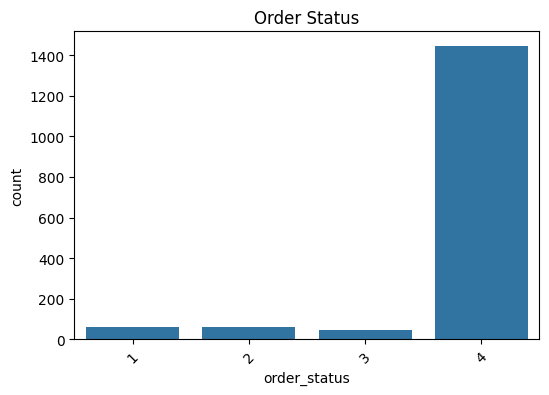

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Now this works
plt.figure(figsize=(6,4))
sns.countplot(data=orders, x='order_status')
plt.title("Order Status")
plt.xticks(rotation=45)
plt.show()

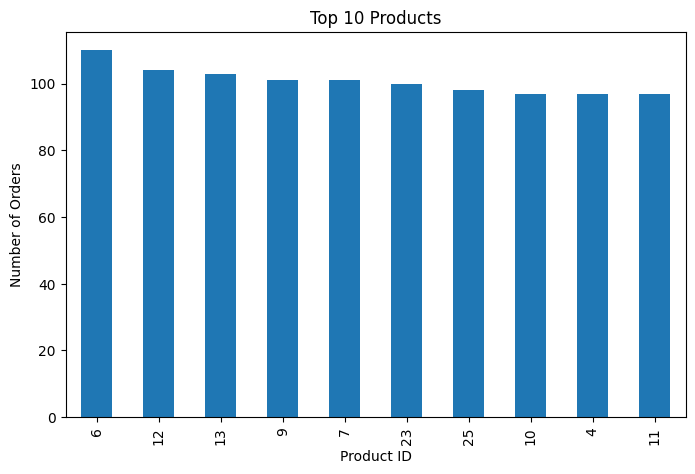

In [30]:
plt.figure(figsize=(8,5))
order_items['product_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")
plt.show()

## To Calculate RFM Features for Customers 

In [31]:
rfm_df = pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner"
)

print("Merged dataframe shape:", rfm_df.shape)
print("Columns:", rfm_df.columns.tolist())

Merged dataframe shape: (4722, 17)
Columns: ['order_id', 'customer_id', 'order_status', 'order_date', 'required_date', 'shipped_date', 'store_id', 'staff_id', 'shipping_status', 'item_id', 'product_id', 'quantity', 'list_price', 'discount', 'Total price', 'Product_Name', 'Category Name']


In [32]:
print(rfm_df["order_date"].unique()[:10])

<StringArray>
['01-01-2016', '01-02-2016', '01-03-2016', '01-04-2016', '01-05-2016',
 '01-06-2016', '01-08-2016', '01-09-2016', '01-12-2016',   '01-14-16']
Length: 10, dtype: str


In [33]:
merged=pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner"
)
print(merged)

      order_id  customer_id  order_status  order_date required_date  \
0            1          259             4  01-01-2016    03-01-2016   
1            1          259             4  01-01-2016    03-01-2016   
2            1          259             4  01-01-2016    03-01-2016   
3            1          259             4  01-01-2016    03-01-2016   
4            1          259             4  01-01-2016    03-01-2016   
...        ...          ...           ...         ...           ...   
4717      1614          135             3    11-28-18    28-11-2018   
4718      1614          135             3    11-28-18    28-11-2018   
4719      1615          136             3    12-28-18    28-12-2018   
4720      1615          136             3    12-28-18    28-12-2018   
4721      1615          136             3    12-28-18    28-12-2018   

     shipped_date  store_id  staff_id shipping_status  item_id  product_id  \
0      03-01-2016         1         2       Delivered        1       

In [34]:
rfm_df["order_date"] = pd.to_datetime(rfm_df["order_date"], format='mixed', dayfirst=False)

print("\nDate range:", rfm_df["order_date"].min(), "to", rfm_df["order_date"].max())


Date range: 2016-01-01 00:00:00 to 2018-12-28 00:00:00


In [35]:
reference_date = rfm_df["order_date"].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

Reference date: 2018-12-29 00:00:00


In [36]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id',
       'shipping_status'],
      dtype='str')


In [37]:
print(rfm_df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id',
       'shipping_status', 'item_id', 'product_id', 'quantity', 'list_price',
       'discount', 'Total price', 'Product_Name', 'Category Name'],
      dtype='str')


In [38]:
rfm_data = rfm_df.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "nunique"),  # Count unique orders
    Monetary=("Total price", "sum")
).reset_index()

print("\nRFM data shape:", rfm_data.shape)
print("\nRFM data summary:")
print(rfm_data.describe())


RFM data shape: (1445, 4)

RFM data summary:
       customer_id      Recency    Frequency      Monetary
count  1445.000000  1445.000000  1445.000000   1445.000000
mean    723.000000   636.640830     1.117647   5936.672187
std     417.279882   253.306495     0.397360   5544.148181
min       1.000000     1.000000     1.000000    109.940000
25%     362.000000   425.000000     1.000000   1897.850000
50%     723.000000   635.000000     1.000000   4361.660000
75%    1084.000000   849.000000     1.000000   8059.470000
max    1445.000000  1093.000000     3.000000  37800.420000


In [39]:
print(rfm_df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_date', 'required_date', 'shipped_date', 'store_id', 'staff_id', 'shipping_status', 'item_id', 'product_id', 'quantity', 'list_price', 'discount', 'Total price', 'Product_Name', 'Category Name']


In [40]:
def segment_customer(row):
    """Segment customers based on monetary value"""
    q75 = rfm_data["Monetary"].quantile(0.75)
    q50 = rfm_data["Monetary"].quantile(0.50)
    
    if row["Monetary"] >= q75:
        return "At Risk"
    elif row["Monetary"] >= q50:
        return "Loyal"
    else:
        return "New"
rfm_data["Customer_Segment"] = rfm_data.apply(segment_customer, axis=1)

In [41]:
print("\nCustomer Segment Distribution:")
print(rfm_data["Customer_Segment"].value_counts())


Customer Segment Distribution:
Customer_Segment
New        722
At Risk    362
Loyal      361
Name: count, dtype: int64


In [42]:
rfm_data.head()

,customer_id,Recency,Frequency,Monetary,Customer_Segment
0,1,41,3,30644.78,At Risk
1,2,264,3,21652.87,At Risk
2,3,69,3,26248.66,At Risk
3,4,255,3,24197.81,At Risk
4,5,256,3,19442.01,At Risk


In [43]:
rfm_data["Customer_Segment"].value_counts()

Customer_Segment
New        722
At Risk    362
Loyal      361
Name: count, dtype: int64

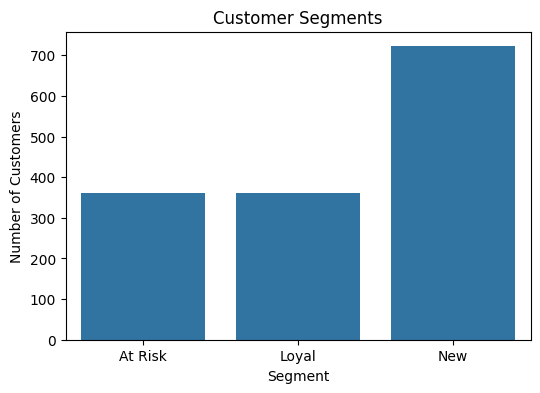

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=rfm_data, x="Customer_Segment")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [45]:
# Option A: Use a different filename
rfm_data.to_csv("customer_segments_new.csv", index=False)

In [46]:
import os
print(os.listdir())

['customer_segments.csv', 'customer_segments_new.csv', 'final er diagram.mwb', 'final er diagram.mwb.bak', 'final sql project.sql', 'order_items.xlsx', 'Untitled-1.ipynb', 'worked file.xlsx']
